# 3.5 图像分类数据集

本节按照《动手学深度学习》3.5 节的知识结构学习 Fashion-MNIST，并使用 PyTorch 完成数据下载、标签转换、图像显示、小批量读取和数据加载函数封装。

原教材：[3.5 图像分类数据集](https://zh.d2l.ai/chapter_linear-networks/image-classification-dataset.html)

## 学习目标

学完本节后，应当能够：

1. 说明训练集、测试集及 Fashion-MNIST 的基本组成；
2. 理解图像张量 `[通道数, 高度, 宽度]` 的含义；
3. 使用 `Dataset` 按索引读取样本，使用 `DataLoader` 按小批量读取样本；
4. 解释 `ToTensor`、`Resize`、`Compose`、`batch_size` 和 `shuffle`；
5. 将数据准备过程封装成可复用函数；
6. 分析数据读取速度及常见优化方法。

In [14]:
import sys  # 导入 sys，用于判断当前操作系统平台
import time  # 导入 time，用于测量数据读取时间
from pathlib import Path  # 导入 Path，用面向对象的方式表示文件路径

import matplotlib.pyplot as plt  # 导入绘图库，用于显示服装图像
import torch  # 导入 PyTorch
import torchvision  # 导入计算机视觉扩展库，里面提供 Fashion-MNIST
from torch.utils import data  # 导入 PyTorch 数据处理模块
from torchvision import transforms  # 导入常用图像变换工具

print("PyTorch 版本:", torch.__version__)  # 显示当前 PyTorch 版本
print("torchvision 版本:", torchvision.__version__)  # 显示 torchvision 版本

PyTorch 版本: 2.13.0+cpu
torchvision 版本: 0.28.0+cpu


## 3.5.1 读取数据集

MNIST 是经典的手写数字分类数据集，但它对现代模型而言过于简单。本节使用外观更复杂、类别边界更模糊的 **Fashion-MNIST**。

Fashion-MNIST 的基本信息：

- 共 10 个服装类别；
- 训练集共 60,000 张图像，每类 6,000 张；
- 测试集共 10,000 张图像，每类 1,000 张；
- 每张图像为 $28\times28$ 的灰度图，通道数为 1；
- 训练集用于学习模型参数，测试集只用于最终评估，不能参与训练。

在 PyTorch 中，一个 `Dataset` 像一张可以按行查询的表：`dataset[i]` 返回第 `i` 个样本及其标签，`len(dataset)` 返回样本总数。

### 图像变换：`ToTensor`

下载得到的单张图像通常是 PIL 图像，像素是 $0\sim255$ 的整数。`transforms.ToTensor()` 会完成两件事：

1. 将图像转换为 `torch.float32` 张量；
2. 将像素除以 255，使其缩放到 $[0,1]$。

输出采用 PyTorch 常用的 **CHW** 排列：

$$
[C,H,W]=[1,28,28],
$$

其中 $C$ 是通道数、$H$ 是高度、$W$ 是宽度。灰度图只有一个通道；普通彩色 RGB 图通常有三个通道。

In [15]:
transform_to_tensor = transforms.ToTensor()  # 创建“PIL 图像转张量”的变换对象
data_root = Path("../data")  # 指定数据保存目录；相对路径以 Notebook 当前工作目录为基准

mnist_train = torchvision.datasets.FashionMNIST(  # 创建 Fashion-MNIST 训练集对象
    root=data_root,  # 指定数据文件的保存位置
    train=True,  # True 表示读取训练集
    transform=transform_to_tensor,  # 每次取出图像时自动执行 ToTensor
    download=True,  # 本地没有数据时自动下载；已有数据时不会重复下载
)

mnist_test = torchvision.datasets.FashionMNIST(  # 创建 Fashion-MNIST 测试集对象
    root=data_root,  # 训练集和测试集使用同一个根目录
    train=False,  # False 表示读取测试集
    transform=transform_to_tensor,  # 使用相同的图像预处理
    download=True,  # 缺少测试集文件时自动下载
)

> 首次运行上面的单元格需要联网下载数据，之后会直接读取本地缓存。`FashionMNIST(...)` 此时只描述“怎样取得一个样本”，并没有预先把所有变换后的图像堆成一个巨大张量。

In [16]:
print("训练集样本数:", len(mnist_train))  # __len__ 返回训练集大小，应为 60000
print("测试集样本数:", len(mnist_test))  # 测试集大小应为 10000

first_image, first_label = mnist_train[0]  # __getitem__(0) 返回元组 (图像, 标签)
print("第一张图像形状:", first_image.shape)  # 应为 [1, 28, 28]
print("图像数据类型:", first_image.dtype)  # ToTensor 后应为 torch.float32
print("像素范围:", first_image.min().item(), first_image.max().item())  # 应在 [0, 1] 内
print("第一张图像标签:", first_label, type(first_label))  # 标签是 0～9 的 Python 整数

训练集样本数: 60000
测试集样本数: 10000
第一张图像形状: torch.Size([1, 28, 28])
图像数据类型: torch.float32
像素范围: 0.0 1.0
第一张图像标签: 9 <class 'int'>


### 必要的 Python 语法：索引与元组解包

`mnist_train[0]` 中的 `[0]` 表示取第一个样本。返回值是 `(image, label)` 二元组，下面两种写法等价：

```python
sample = mnist_train[0]
image = sample[0]
label = sample[1]

# 元组解包：按位置直接赋给两个变量
image, label = mnist_train[0]
```

元组解包让数据读取代码更简洁，也是训练循环中 `for X, y in train_iter:` 的语法基础。

### 数字标签与文本标签

模型使用 $0\sim9$ 的整数标签进行计算，人更容易理解类别名称。Fashion-MNIST 的标签依次是 T 恤、裤子、套衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包和短靴。

In [17]:
def get_fashion_mnist_labels(labels):  # 定义数字标签转文本标签的函数
    """将一批 Fashion-MNIST 数字标签转换为文本名称。"""
    text_labels = [  # 列表下标正好对应类别编号 0～9
        "t-shirt", "trouser", "pullover", "dress", "coat",
        "sandal", "shirt", "sneaker", "bag", "ankle boot",
    ]
    return [text_labels[int(label)] for label in labels]  # 使用列表推导式逐个完成转换

example_labels = torch.tensor([0, 2, 6, 9])  # 构造一组示例数字标签
print(get_fashion_mnist_labels(example_labels))  # 查看转换后的文本名称

['t-shirt', 'pullover', 'shirt', 'ankle boot']


这里的列表推导式

```python
[text_labels[int(label)] for label in labels]
```

等价于先创建空列表，再循环执行 `append`。`int(label)` 把零维张量转换为 Python 整数，随后才能把它作为列表下标。

In [18]:
def show_images(images, num_rows, num_cols, titles=None, scale=1.5):  # 定义网格显示函数
    """在 num_rows × num_cols 的网格中显示多张图像。"""
    figure_size = (num_cols * scale, num_rows * scale)  # 根据行列数计算画布尺寸
    _, axes = plt.subplots(num_rows, num_cols, figsize=figure_size)  # 创建画布和子图
    axes = axes.flatten()  # 将二维子图数组展平，方便使用一个循环遍历

    for index, (axis, image) in enumerate(zip(axes, images)):  # 同时遍历子图和图像
        if torch.is_tensor(image):  # 判断图像是否为 PyTorch 张量
            image = image.detach().cpu().numpy()  # 转到 CPU，再转换为 NumPy 数组
        axis.imshow(image, cmap="gray")  # 用灰度色图显示二维图像
        axis.get_xaxis().set_visible(False)  # 隐藏横轴刻度
        axis.get_yaxis().set_visible(False)  # 隐藏纵轴刻度
        if titles is not None:  # 只有传入标题时才设置标题
            axis.set_title(titles[index])  # 标题下标与图像下标对应

    return axes  # 返回子图，便于调用者继续修改样式

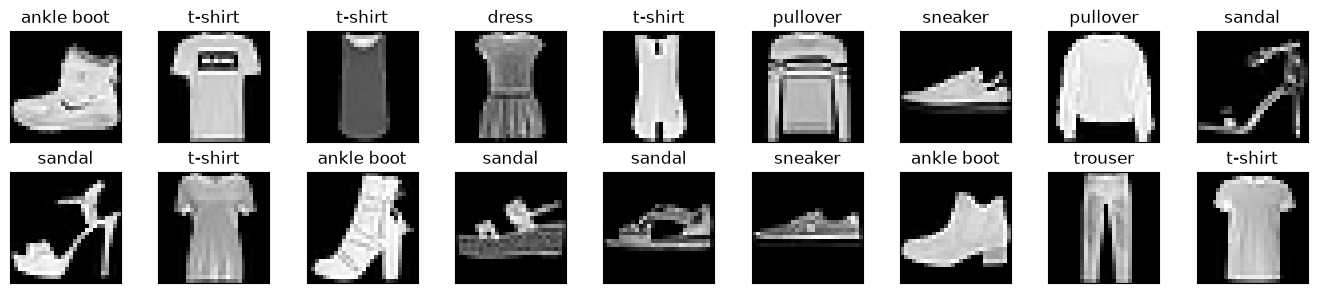

In [19]:
sample_loader = data.DataLoader(mnist_train, batch_size=18, shuffle=False)  # 顺序取前 18 个样本
sample_images, sample_labels = next(iter(sample_loader))  # 取迭代器产生的第一个小批量

show_images(  # 显示 2 行 9 列图像
    sample_images.reshape(18, 28, 28),  # 去掉大小为 1 的通道维，得到 18 张二维图像
    num_rows=2,  # 设置两行
    num_cols=9,  # 设置九列
    titles=get_fashion_mnist_labels(sample_labels),  # 将数字标签转换为标题
)
plt.tight_layout()  # 自动调整间距，减少标题重叠
plt.show()  # 显示图像

## 3.5.2 读取小批量

`Dataset` 负责回答“第 $i$ 个样本是什么”，`DataLoader` 负责回答“怎样把很多样本组织成可迭代的小批量”。

若批量大小为 $B$，单张图像形状为 $[1,28,28]$，那么一批图像的形状为

$$
[B,1,28,28].
$$

`shuffle=True` 会在每轮迭代开始时重新打乱训练样本的访问顺序，避免批量长期带有固定顺序偏差。测试集不参与参数更新，通常使用 `shuffle=False`，保证评估过程稳定且便于复现。

In [20]:
def get_dataloader_workers():  # 定义选择数据加载进程数的函数
    """Windows Notebook 默认使用 0，其他平台使用 4 个子进程。"""
    return 0 if sys.platform.startswith("win") else 4  # 条件表达式：条件成立取 0，否则取 4

batch_size = 256  # 每次读取 256 个样本
num_workers = get_dataloader_workers()  # 根据平台选择后台数据加载进程数

train_iter = data.DataLoader(  # 创建训练集数据加载器
    mnist_train,  # 指定训练数据集
    batch_size=batch_size,  # 指定每批样本数
    shuffle=True,  # 每轮训练前打乱样本顺序
    num_workers=num_workers,  # 指定并行读取数据的子进程数
)

test_iter = data.DataLoader(  # 创建测试集数据加载器
    mnist_test,  # 指定测试数据集
    batch_size=batch_size,  # 测试时也分批，避免一次占用过多内存
    shuffle=False,  # 测试集不需要打乱
    num_workers=num_workers,  # 使用相同的平台兼容设置
)

In [21]:
batch_images, batch_labels = next(iter(train_iter))  # 获取训练加载器的第一个批量

print("图像批量形状:", batch_images.shape)  # [256, 1, 28, 28]
print("图像类型:", batch_images.dtype)  # torch.float32
print("标签批量形状:", batch_labels.shape)  # [256]
print("标签类型:", batch_labels.dtype)  # 分类标签通常为 torch.int64
print("训练批次数:", len(train_iter))  # ceil(60000 / 256) = 235
print("最后一批大小:", len(mnist_train) % batch_size)  # 余数 96，即最后一批有 96 个样本

图像批量形状: torch.Size([256, 1, 28, 28])
图像类型: torch.float32
标签批量形状: torch.Size([256])
标签类型: torch.int64
训练批次数: 235
最后一批大小: 96


### 必要的 Python 语法：`iter` 与 `next`

- `iter(train_iter)` 根据可迭代对象创建迭代器；
- `next(...)` 从迭代器中取得下一项；
- 一项就是一个 `(X, y)` 小批量；
- `for X, y in train_iter:` 会自动重复调用迭代机制，直到遍历完整个数据集。

`len(train_iter)` 是批次数而不是样本数。默认 `drop_last=False`，所以不足一个完整批量的最后 96 个样本仍会被保留。

In [22]:
start_time = time.perf_counter()  # 记录高精度开始时间
number_of_examples = 0  # 用于累计本轮实际读取的样本数

for images, labels in train_iter:  # 遍历训练集的所有小批量
    number_of_examples += images.shape[0]  # 第一维就是当前批量的样本数

elapsed_time = time.perf_counter() - start_time  # 计算遍历一轮所用秒数
throughput = number_of_examples / elapsed_time  # 计算每秒读取的样本数量

print(f"读取样本数: {number_of_examples}")  # f-string 会把变量值嵌入字符串
print(f"读取时间: {elapsed_time:.3f} 秒")  # :.3f 表示保留三位小数
print(f"吞吐量: {throughput:.0f} 个样本/秒")  # :.0f 表示不显示小数位

读取样本数: 60000
读取时间: 8.236 秒
吞吐量: 7285 个样本/秒


### 为什么数据迭代器的速度重要

训练通常由“读取和预处理数据 → 将数据送入设备 → 前向传播与反向传播”组成。如果模型已经算完上一批数据，却仍在等待下一批数据，GPU 或 CPU 就会空闲。

`num_workers>0` 可以让多个子进程并行准备数据。但是进程创建和通信也有成本，并非越多越快。最佳值受到操作系统、CPU 核数、存储速度、变换复杂度、内存容量和模型计算速度共同影响，必须在目标机器上测量。

在 Windows 的交互式 Notebook 中，多进程加载容易因为子进程重复启动 Notebook 代码而报错，所以本节默认使用 `num_workers=0`。在普通 `.py` 脚本中，可以把入口代码放进 `if __name__ == "__main__":` 后再尝试增加进程数。

## 3.5.3 整合所有组件

下面把数据集、图像变换和数据加载器封装为 `load_data_fashion_mnist`。后续章节只需指定批量大小，即可取得训练和测试迭代器。

可选参数 `resize` 用于把原始 $28\times28$ 图像缩放到指定大小。它既可以是整数，如 `64`，也可以是 `(高度, 宽度)` 元组，如 `(32, 48)`。

In [23]:
def load_data_fashion_mnist(batch_size, resize=None):  # 定义可复用的数据加载函数
    """下载 Fashion-MNIST，并返回训练集与测试集的数据迭代器。"""
    transform_steps = [transforms.ToTensor()]  # 默认只把 PIL 图像转换为 [0, 1] 浮点张量

    if resize is not None:  # 如果调用者指定了目标图像尺寸
        transform_steps.insert(0, transforms.Resize(resize))  # 在 ToTensor 之前插入缩放操作

    transform_pipeline = transforms.Compose(transform_steps)  # 将多个变换按列表顺序串联

    train_dataset = torchvision.datasets.FashionMNIST(  # 创建训练数据集
        root=data_root, train=True, transform=transform_pipeline, download=True
    )
    test_dataset = torchvision.datasets.FashionMNIST(  # 创建测试数据集
        root=data_root, train=False, transform=transform_pipeline, download=True
    )

    loader_options = {  # 字典集中保存两个加载器共用的关键字参数
        "batch_size": batch_size,  # 每个小批量包含的样本数
        "num_workers": get_dataloader_workers(),  # 数据读取子进程数
    }

    train_loader = data.DataLoader(  # 创建训练迭代器
        train_dataset, shuffle=True, **loader_options  # ** 将字典展开成关键字参数
    )
    test_loader = data.DataLoader(  # 创建测试迭代器
        test_dataset, shuffle=False, **loader_options  # 测试集保持固定顺序
    )
    return train_loader, test_loader  # 用一个元组返回两个迭代器

这里的 `**loader_options` 是字典解包。若字典为

```python
{"batch_size": 32, "num_workers": 0}
```

那么 `DataLoader(dataset, **loader_options)` 等价于 `DataLoader(dataset, batch_size=32, num_workers=0)`。这样可避免重复书写训练集和测试集共有的配置。

In [24]:
resized_train_iter, resized_test_iter = load_data_fashion_mnist(  # 调用封装后的函数
    batch_size=32,  # 每批读取 32 张图像
    resize=64,  # 将图像的高度和宽度都缩放为 64
)

resized_images, resized_labels = next(iter(resized_train_iter))  # 取得一个缩放后的批量
print("缩放后的图像形状:", resized_images.shape)  # 应为 [32, 1, 64, 64]
print("图像数据类型:", resized_images.dtype)  # 应为 torch.float32
print("标签形状:", resized_labels.shape)  # 应为 [32]
print("标签数据类型:", resized_labels.dtype)  # 应为 torch.int64

缩放后的图像形状: torch.Size([32, 1, 64, 64])
图像数据类型: torch.float32
标签形状: torch.Size([32])
标签数据类型: torch.int64


## 本节知识与代码梳理

一批数据到达模型前，依次经过以下组件：

$$
\text{磁盘中的原始图像}
\longrightarrow \text{FashionMNIST Dataset}
\longrightarrow \text{Resize/ToTensor}
\longrightarrow \text{DataLoader 组批与打乱}
\longrightarrow (X,y).
$$

对应关系：

| 组件 | 主要职责 | 典型结果 |
|---|---|---|
| `FashionMNIST` | 定位、下载并按索引读取样本 | `(image, label)` |
| `Resize` | 修改图像空间尺寸 | $28\times28\to64\times64$ |
| `ToTensor` | 转张量、转 CHW、缩放像素 | `float32 [1,H,W]` |
| `DataLoader` | 打乱、组批、并行加载 | `X: [B,1,H,W]`, `y: [B]` |
| `load_data_fashion_mnist` | 封装完整流程 | `(train_iter, test_iter)` |

最重要的区分是：`Dataset` 管理单个样本，`DataLoader` 管理如何迭代和组织一批样本。

## 3.5.4 小结

- Fashion-MNIST 包含 10 类服装图像，训练集和测试集分别有 60,000 与 10,000 个样本。
- 每张原始图像是 $28\times28$ 灰度图，在 PyTorch 中通常表示为 `[1, 28, 28]`。
- `ToTensor` 将图像转换为浮点张量，并把像素缩放到 $[0,1]$。
- `Dataset` 提供单个样本，`DataLoader` 负责打乱、组批和并行加载。
- 训练集通常打乱，测试集通常保持固定顺序。
- 数据读取速度可能限制训练性能，加载参数需要根据实际硬件测量。
- 将数据准备过程封装成函数，可以让后续模型实现专注于网络、损失和优化。

## 3.5.5 练习

1. 减少 `batch_size`（例如减少到 1）是否会影响读取性能？
2. 数据迭代器的性能非常重要。当前实现足够快吗？探索各种选择来改进它。
3. 查阅框架的在线 API 文档。还有哪些其他数据集可用？

## 3.5.6 练习题参考答案

以下答案强调分析方法。性能题没有对所有机器都成立的固定数字，应在自己的运行环境中测量。

### 练习 1 答案

把 `batch_size` 从 256 减少到 1，通常会明显降低整体读取吞吐量，原因包括：

1. 读取 60,000 个样本时，批量数从 $\lceil60000/256\rceil=235$ 增加到 60,000；
2. 每次迭代、函数调用、张量组装及进程通信都有固定开销；
3. 小批量无法充分利用向量化运算、连续内存访问和设备并行能力；
4. 若训练模型，频繁进行很小的数据传输也会降低 GPU 利用率。

但批量越大也不一定越好。大批量占用更多内存，并可能增加产生第一批数据的等待时间。训练时还会影响优化过程。因此应同时考虑：

- 每秒读取或训练的样本数；
- 内存或显存占用；
- 模型最终精度；
- 单批延迟。

结论：减小到 1 通常使吞吐量下降，但具体差距必须实测。

In [25]:
def benchmark_batch_sizes(dataset, batch_sizes, max_batches=None):  # 定义批量大小测试函数
    """返回不同 batch_size 对应的读取吞吐量。"""
    results = {}  # 用字典保存“批量大小 -> 每秒样本数”

    for current_batch_size in batch_sizes:  # 逐个测试候选批量大小
        loader = data.DataLoader(  # 为当前批量大小创建独立加载器
            dataset,
            batch_size=current_batch_size,
            shuffle=False,
            num_workers=get_dataloader_workers(),
        )
        start = time.perf_counter()  # 开始计时
        sample_count = 0  # 清零已读取样本数

        for batch_index, (images, _) in enumerate(loader):  # _ 表示本次不使用标签
            sample_count += images.shape[0]  # 累计当前批量样本数
            if max_batches is not None and batch_index + 1 >= max_batches:  # 可选提前结束
                break

        seconds = time.perf_counter() - start  # 得到测试耗时
        results[current_batch_size] = sample_count / seconds  # 保存吞吐量

    return results  # 返回所有测量结果

batch_size_results = benchmark_batch_sizes(  # 在当前机器上进行公平对比
    mnist_train,
    batch_sizes=[1, 32, 128, 256],
    max_batches=200,  # 控制练习运行时间；需要完整测量时可改为 None
)
for tested_batch_size, speed in batch_size_results.items():  # 遍历字典键值对
    print(f"batch_size={tested_batch_size:>3}: {speed:>8.0f} 个样本/秒")

batch_size=  1:     4151 个样本/秒
batch_size= 32:     6784 个样本/秒
batch_size=128:     7332 个样本/秒
batch_size=256:     7159 个样本/秒


### 练习 2 答案

“当前实现是否足够快”应通过比较**数据准备时间**与**模型计算时间**判断。如果模型经常等待数据，或者只遍历数据就占据每轮训练的大部分时间，则不够快。

可尝试以下改进：

1. 调整 `num_workers`，测试 `0、2、4、8` 等值；最佳值通常不超过可用 CPU 核心数；
2. 在 CUDA 训练中启用 `pin_memory=True`，并用 `.to(device, non_blocking=True)` 尝试异步传输；
3. 当 `num_workers>0` 时使用 `persistent_workers=True`，避免每轮重新创建子进程；
4. 调整 `prefetch_factor`，让每个工作进程提前准备更多批量；
5. 减少过于昂贵的 Python 图像变换，或把可复用结果预处理并缓存；
6. 将数据放在更快的本地 SSD，避免慢速网络盘和大量零碎文件造成的随机读取；
7. 在内存允许时适当增大 `batch_size`；
8. 先进行一次预热，再重复测量多轮并取中位数，避免把下载、缓存和进程启动时间混入结论。

注意：`pin_memory` 主要服务于 CPU 到 CUDA 的传输，纯 CPU 训练通常不会因此受益。`persistent_workers` 和 `prefetch_factor` 只适用于 `num_workers>0`。Windows Notebook 中应优先保证代码能够稳定运行，再在 `.py` 脚本中测试多进程。

In [26]:
def make_optimized_loader(dataset, batch_size, shuffle, num_workers=0):  # 构造可调加载器
    """根据工作进程数量安全地添加性能选项。"""
    loader_kwargs = {  # 创建基础配置字典
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": num_workers,
        "pin_memory": torch.cuda.is_available(),  # 只有 CUDA 可用时才锁页内存
    }

    if num_workers > 0:  # 这些参数要求至少存在一个数据加载子进程
        loader_kwargs["persistent_workers"] = True  # 每轮结束后保留工作进程
        loader_kwargs["prefetch_factor"] = 2  # 每个工作进程提前准备两个批量

    return data.DataLoader(dataset, **loader_kwargs)  # 解包配置并创建加载器

# Windows Notebook 中先使用 num_workers=0；脚本环境可测试 2、4 等值
optimized_train_iter = make_optimized_loader(
    mnist_train, batch_size=256, shuffle=True, num_workers=get_dataloader_workers()
)
print(optimized_train_iter)

### 练习 3 答案

`torchvision.datasets` 还提供许多计算机视觉数据集。例如：

| 任务 | 数据集示例 |
|---|---|
| 手写字符分类 | `MNIST`、`EMNIST`、`KMNIST`、`QMNIST`、`USPS` |
| 小型自然图像分类 | `CIFAR10`、`CIFAR100`、`SVHN`、`STL10` |
| 大型图像分类 | `ImageNet`、`Places365`、`ImageFolder` |
| 人脸与属性 | `CelebA`、`LFWPeople`、`WIDERFace` |
| 目标检测与分割 | `CocoDetection`、`VOCDetection`、`VOCSegmentation`、`Cityscapes`、`KITTI` |
| 视频 | `UCF101`、`HMDB51`、`Kinetics` |
| 测试数据流水线 | `FakeData` |

这些数据集通常都实现了 `__len__` 和 `__getitem__`，因此可以交给 `DataLoader`。但它们并非都支持自动下载；ImageNet、COCO 等数据集可能要求用户先按官方目录结构准备图像和标注。不同数据集返回的标签结构也不同：分类任务通常返回整数，检测任务可能返回边界框和字典。

可用数据集会随 torchvision 版本变化，应查看当前版本的官方文档：

- [torchvision 内置数据集](https://docs.pytorch.org/vision/stable/datasets.html)
- [PyTorch Dataset 与 DataLoader 教程](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)